# 對抗攻防 Pipeline · MNIST & Fashion-MNIST（FGSM / iFGSM / C&W）

以兩個資料集各自訓練 **baseline CNN**，作為對抗訓練與防禦成效比較的基礎，分三大區：

- **第 1 區 · 攻擊前**：兩個 baseline 模型在原始測試集的整體 / 各類別 accuracy、confusion matrix、precision、recall。
- **第 2 區 · 攻擊後**：每個資料集展示 10 組「乾淨 vs 對抗」樣本；三種攻擊各自掃描 epsilon，量測 baseline 的 ASR 與 accuracy。
- **第 3 區 · 防禦後**：線上對抗訓練（**只做分別訓練，不含混合攻擊**），每個資料集對每種攻擊各得一個專屬防禦模型（ε=0.05、從頭訓練 3 epoch）。

> **重要**：FGSM / iFGSM / C&W 的 epsilon 意義不同，因此每種攻擊各用**獨立圖表**呈現攻擊前 / 攻擊後 / 防禦後，不將三種攻擊疊在同一張圖。


In [1]:
import sys, os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

# 專案根目錄：從當前資料夾往上找到含 src/ 的目錄
# （notebook 放在 notebooks/ 底下、或從專案根執行都能運作）
ROOT = os.path.abspath('.')
while not os.path.isdir(os.path.join(ROOT, 'src')) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
for p in ['src/attacks', 'src/defense', 'src/models']:
    sys.path.append(os.path.join(ROOT, p))

from mnist_net import mnistNet
from adv_train import make_generators, adversarial_train, METHODS

In [2]:
# ===================== 全域設定 =====================
DATASETS = ["MNIST", "FashionMNIST"]      # 兩個資料集都會跑
ATTACKS  = ["FGSM", "iFGSM", "C&W"]        # 三種攻擊（各自獨立分析，不互相比較）

DATA_ROOT = os.path.join(ROOT, "data", "datasets")   # 原始資料集
MODEL_DIR = os.path.join(ROOT, "checkpoints")        # baseline / 防禦權重
IMG_DIR   = os.path.join(ROOT, "data", "img")        # 輸出圖表
os.makedirs(IMG_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 中文字型（Windows）
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# --- 攻擊掃描 epsilon（每種攻擊各自一組，意義不同故不互相比較）---
ATTACK_EPS = {
    "FGSM":  [0.01, 0.03, 0.05, 0.08, 0.10],
    "iFGSM": [0.01, 0.03, 0.05, 0.08, 0.10],
    "C&W":   [0.01, 0.03, 0.05, 0.08, 0.10],
}

# 攻擊評估時的迭代參數
IFGSM_ITERS = 10
CW_ITERS    = 20
CW_LR       = 0.01

# --- 第 3 區：線上對抗訓練參數 ---
ADV_EPS           = 0.05   # 訓練時對抗樣本擾動強度
DEF_EPOCHS        = 30      
IFGSM_TRAIN_ITERS = 10
CW_TRAIN_ITERS    = 10
LR                = 1e-3
BASE_EPOCHS       = 5      # 若找不到 baseline 檔才會訓練
# CPU 很慢：每 epoch 只跑前 N 個 batch；設 None 用全部訓練集
TRAIN_MAX_BATCHES = 150
FORCE_RETRAIN_DEF = False  # True 則忽略既有防禦權重、重新訓練

# --- 評估用測試子集（None = 全部 10000 張）---
EVAL_SUBSET = 1000
BATCH_SIZE  = 128

CLASS_NAMES = {
    "MNIST": [str(i) for i in range(10)],
    "FashionMNIST": ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                     'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'],
}

def prefix_of(name):      return name.lower()
def baseline_ckpt(name):
    return os.path.join(MODEL_DIR,
        "mnist_cnn_no_dropout.pt" if name == "MNIST" else "fashion_mnist_cnn_no_dropout.pt")
def defense_ckpt(name, attack):
    tag = attack.replace("&", "").lower()          
    return os.path.join(MODEL_DIR, f"{prefix_of(name)}_def_{tag}.pt")

print("裝置:", device, "| 資料集:", DATASETS, "| 攻擊:", ATTACKS)
print("ROOT:", ROOT)

裝置: cuda | 資料集: ['MNIST', 'FashionMNIST'] | 攻擊: ['FGSM', 'iFGSM', 'C&W']
ROOT: /home/karla/0707FGSM


In [3]:
# ===================== 共用函式 =====================
transform = transforms.Compose([transforms.ToTensor()])

def get_datasets(name):
    cls = datasets.MNIST if name == "MNIST" else datasets.FashionMNIST
    tr = cls(DATA_ROOT, train=True,  download=True, transform=transform)
    te = cls(DATA_ROOT, train=False, download=True, transform=transform)
    return tr, te

def train_baseline(model, loader, epochs):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    crit = nn.NLLLoss()
    for e in range(1, epochs + 1):
        running = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward(); opt.step()
            running += loss.item()
        print(f"    Epoch {e}/{epochs}  loss={running/len(loader):.4f}")
    return model

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total

@torch.no_grad()
def get_preds(model, loader):
    model.eval(); ys, ps = [], []
    for x, y in loader:
        x = x.to(device)
        ps.append(model(x).argmax(1).cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(ps)

def report_baseline(name, model, test_loader):
    """整體 / 各類別 accuracy、confusion matrix、precision、recall。"""
    names = CLASS_NAMES[name]
    y_true, y_pred = get_preds(model, test_loader)
    acc = float((y_true == y_pred).mean())
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)          
    rep = classification_report(y_true, y_pred, target_names=names,
                                digits=4, output_dict=True, zero_division=0)

    print(f"\n★ [{name}] 攻擊前 Clean Accuracy = {acc:.4f}")
    tbl = pd.DataFrame({
        "Accuracy(per-class)": per_class_acc,
        "Precision": [rep[c]["precision"] for c in names],
        "Recall":    [rep[c]["recall"]    for c in names],
        "F1":        [rep[c]["f1-score"]  for c in names],
        "Support":   [int(rep[c]["support"]) for c in names],
    }, index=names)
    display(tbl.round(4))
    print(f"Macro  Precision={rep['macro avg']['precision']:.4f}  "
          f"Recall={rep['macro avg']['recall']:.4f}")

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ConfusionMatrixDisplay(cm, display_labels=names).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d",
        xticks_rotation=45 if name == "FashionMNIST" else 0)
    ax.set_title(f"{name} · Confusion Matrix (Clean, acc={acc:.3f})")
    plt.tight_layout()
    plt.savefig(os.path.join(IMG_DIR, f"{prefix_of(name)}_confusion.png"), dpi=150)
    plt.show()
    return acc

def gen_for(model, attack, eps):
    """取得綁定該 model 的單一攻擊即時生成函式（與訓練用同一套生成器，確保一致）。"""
    gens = make_generators(model, device, eps,
                           ifgsm_iters=IFGSM_ITERS, cw_iters=CW_ITERS, cw_lr=CW_LR)
    return gens[attack]

def eval_attack(model, loader, attack, eps):
    """回傳 (ASR, accuracy_under_attack)。
       ASR = 原本答對卻被翻掉的比例；accuracy = 對抗樣本上的整體正確率。"""
    g = gen_for(model, attack, eps)
    model.eval()
    total = correct_adv = correct_clean = flips = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            clean_pred = model(x).argmax(1)
        x_adv = g(x, y)                       # 需要梯度，故不包 no_grad
        with torch.no_grad():
            adv_pred = model(x_adv).argmax(1)
        cmask = (clean_pred == y)
        correct_clean += cmask.sum().item()
        flips += ((adv_pred != clean_pred) & cmask).sum().item()
        correct_adv += (adv_pred == y).sum().item()
        total += y.size(0)
    asr = flips / correct_clean if correct_clean > 0 else 0.0
    return asr, correct_adv / total

def sweep(model, loader, attack):
    eps_list = ATTACK_EPS[attack]
    asr, acc = [], []
    for e in eps_list:
        a, c = eval_attack(model, loader, attack, e)
        asr.append(a); acc.append(c)
        print(f"      {attack:5s} eps={e:.2f}  ASR={a:.3f}  acc={c:.3f}")
    return eps_list, asr, acc

def show_pairs(name, model, dataset, attack="FGSM", eps=0.05, n=10):
    """展示 n 組乾淨 vs 對抗樣本（含真實 label 與模型預測）。"""
    names = CLASS_NAMES[name]
    xs = torch.stack([dataset[i][0] for i in range(n)]).to(device)
    ys = torch.tensor([dataset[i][1] for i in range(n)]).to(device)
    g = gen_for(model, attack, eps)
    model.eval()
    with torch.no_grad():
        clean_pred = model(xs).argmax(1)
    x_adv = g(xs, ys)
    with torch.no_grad():
        adv_pred = model(x_adv).argmax(1)

    # 加高整體畫布並拉大上下兩列間距，避免標題被擋住
    fig, axes = plt.subplots(2, n, figsize=(1.5 * n, 5.0),
                             gridspec_kw={'hspace': 0.55})
    for i in range(n):
        yi, cpi, api = int(ys[i]), int(clean_pred[i]), int(adv_pred[i])
        axes[0, i].imshow(xs[i, 0].cpu(), cmap="gray"); axes[0, i].axis("off")
        axes[0, i].set_title(f"y={names[yi]}\np={names[cpi]}", fontsize=8)
        axes[1, i].imshow(x_adv[i, 0].cpu(), cmap="gray"); axes[1, i].axis("off")
        col = "green" if api == yi else "red"
        axes[1, i].set_title(f"p={names[api]}", fontsize=8, color=col)
    axes[0, 0].set_ylabel("Clean",       fontsize=10); axes[0, 0].axis("on"); axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])
    axes[1, 0].set_ylabel(f"Adv({attack})", fontsize=10); axes[1, 0].axis("on"); axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([])
    fig.suptitle(f"{name} · Clean vs Adversarial（{attack}, eps={eps}）", fontsize=13)
    # rect 幫 suptitle 留頂部空間；h_pad 加大列距，讓兩行標題不被下一張圖蓋住
    plt.tight_layout(rect=[0, 0, 1, 0.93], h_pad=2.5)
    plt.savefig(os.path.join(IMG_DIR, f"{prefix_of(name)}_pairs.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

def plot_attack_chart(name, attack, res, clean_acc):
    """單一攻擊的獨立圖表：ASR 下降（左）＋ accuracy 恢復（右）。"""
    eps = res["eps"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

    ax1.plot(eps, res["asr_base"], "o-",  color="#E74C3C", lw=2.2, label="攻擊後 (baseline)")
    ax1.plot(eps, res["asr_def"],  "s--", color="#27AE60", lw=2.2, label="防禦後 (對抗訓練)")
    ax1.set_title(f"{name} · {attack} — Attack Success Rate")
    ax1.set_xlabel("epsilon"); ax1.set_ylabel("ASR"); ax1.set_ylim(0, 1)
    ax1.grid(True, ls=":", alpha=0.4); ax1.legend()

    ax2.axhline(clean_acc, color="#7F8C8D", ls=":", lw=2, label="攻擊前 clean acc")
    ax2.plot(eps, res["acc_base"], "o-",  color="#E74C3C", lw=2.2, label="攻擊後 (baseline)")
    ax2.plot(eps, res["acc_def"],  "s--", color="#27AE60", lw=2.2, label="防禦後 (對抗訓練)")
    ax2.set_title(f"{name} · {attack} — Accuracy")
    ax2.set_xlabel("epsilon"); ax2.set_ylabel("accuracy"); ax2.set_ylim(0, 1)
    ax2.grid(True, ls=":", alpha=0.4); ax2.legend()

    plt.tight_layout()
    tag = attack.replace("&", "").lower()
    plt.savefig(os.path.join(IMG_DIR, f"{prefix_of(name)}_chart_{tag}.png"), dpi=160)
    plt.show()

# 全域狀態
BASE, DEF, DATA, SWEEP, CLEAN_ACC = {}, {}, {}, {}, {}

## 第 1 區 · 攻擊前（Baseline 模型基礎表現）

兩個資料集各自載入 / 訓練 baseline CNN，記錄整體與各類別 accuracy、confusion matrix、precision、recall。

In [4]:
for name in DATASETS:
    print(f"===== 準備 {name} baseline =====")
    train_set, test_set = get_datasets(name)
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_set,  batch_size=512, shuffle=False)
    eval_base = test_set if EVAL_SUBSET is None else Subset(test_set, range(EVAL_SUBSET))
    eval_loader = DataLoader(eval_base, batch_size=256, shuffle=False)
    DATA[name] = dict(train_set=train_set, test_set=test_set,
                      train_loader=train_loader, test_loader=test_loader,
                      eval_loader=eval_loader)

    model = mnistNet().to(device)
    ckpt = baseline_ckpt(name)
    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=device))
        print(f"  已載入 baseline：{ckpt}")
    else:
        print("  找不到 baseline，開始訓練…")
        train_baseline(model, train_loader, epochs=BASE_EPOCHS)
        torch.save(model.state_dict(), ckpt)
    BASE[name] = model

===== 準備 MNIST baseline =====
  已載入 baseline：/home/karla/0707FGSM/checkpoints/mnist_cnn_no_dropout.pt
===== 準備 FashionMNIST baseline =====
  已載入 baseline：/home/karla/0707FGSM/checkpoints/fashion_mnist_cnn_no_dropout.pt



★ [MNIST] 攻擊前 Clean Accuracy = 0.9899


,Accuracy(per-class),Precision,Recall,F1,Support
0,0.9969,0.9889,0.9969,0.9929,980
1,0.9938,0.9947,0.9938,0.9943,1135
2,0.9922,0.9865,0.9922,0.9894,1032
3,0.9921,0.9901,0.9921,0.9911,1010
4,0.9929,0.9919,0.9929,0.9924,982
5,0.9899,0.9877,0.9899,0.9888,892
6,0.9885,0.9937,0.9885,0.9911,958
7,0.9844,0.9883,0.9844,0.9864,1028
8,0.9846,0.9876,0.9846,0.9861,974
9,0.9832,0.9890,0.9832,0.9861,1009


findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

Macro  Precision=0.9898  Recall=0.9899


findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

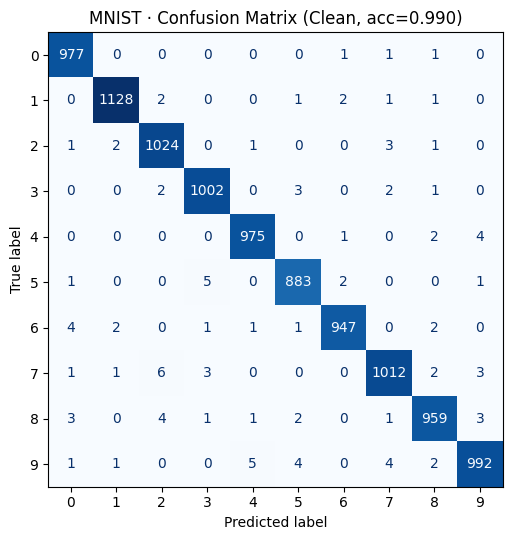


★ [FashionMNIST] 攻擊前 Clean Accuracy = 0.9169


,Accuracy(per-class),Precision,Recall,F1,Support
T-shirt/top,0.861,0.8786,0.861,0.8697,1000
Trouser,0.988,0.9715,0.988,0.9797,1000
Pullover,0.861,0.8706,0.861,0.8658,1000
Dress,0.911,0.9344,0.911,0.9225,1000
Coat,0.891,0.8430,0.891,0.8663,1000
Sandal,0.982,0.9869,0.982,0.9845,1000
Shirt,0.760,0.7731,0.760,0.7665,1000
Sneaker,0.977,0.9522,0.977,0.9645,1000
Bag,0.979,0.9800,0.979,0.9795,1000
Ankle boot,0.959,0.9796,0.959,0.9692,1000


findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

Macro  Precision=0.9170  Recall=0.9169


findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

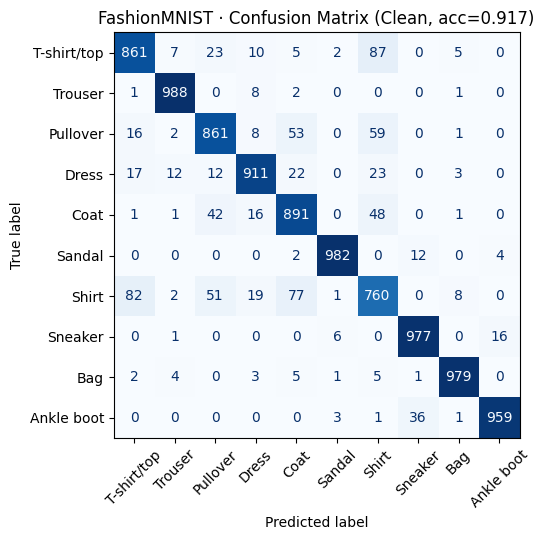

In [5]:
for name in DATASETS:
    CLEAN_ACC[name] = report_baseline(name, BASE[name], DATA[name]["test_loader"])

## 第 2 區 · 攻擊後

每個資料集展示 10 組乾淨 vs 對抗樣本，並對 baseline 掃描三種攻擊的 epsilon（ASR 與 accuracy）。

/tmp/ipykernel_5191/1914418490.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93], h_pad=2.5)
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families w

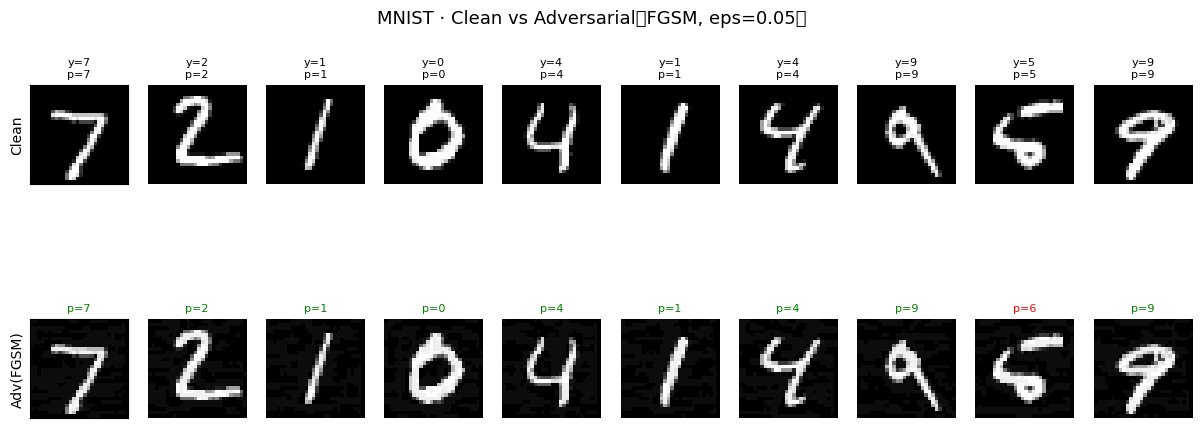

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

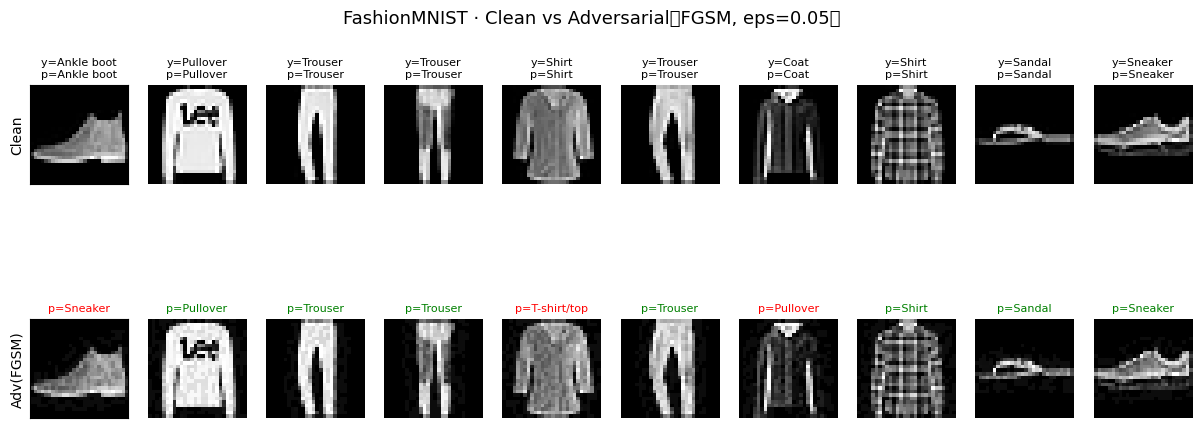

In [6]:
# 10 組乾淨 vs 對抗樣本（以 FGSM, eps=0.05 示意；可改 attack / eps）
for name in DATASETS:
    show_pairs(name, BASE[name], DATA[name]["test_set"], attack="FGSM", eps=0.05, n=10)

In [7]:
# 對 baseline 掃描三種攻擊（heavy：C&W 最慢）
for name in DATASETS:
    SWEEP[name] = {}
    print(f"===== [{name}] 攻擊 baseline =====")
    for attack in ATTACKS:
        eps, asr, acc = sweep(BASE[name], DATA[name]["eval_loader"], attack)
        SWEEP[name][attack] = dict(eps=eps, asr_base=asr, acc_base=acc)

===== [MNIST] 攻擊 baseline =====
      FGSM  eps=0.01  ASR=0.006  acc=0.983
      FGSM  eps=0.03  ASR=0.021  acc=0.968
      FGSM  eps=0.05  ASR=0.030  acc=0.959
      FGSM  eps=0.08  ASR=0.074  acc=0.916
      FGSM  eps=0.10  ASR=0.125  acc=0.865
      iFGSM eps=0.01  ASR=0.007  acc=0.982
      iFGSM eps=0.03  ASR=0.023  acc=0.966
      iFGSM eps=0.05  ASR=0.035  acc=0.954
      iFGSM eps=0.08  ASR=0.111  acc=0.879
      iFGSM eps=0.10  ASR=0.210  acc=0.781
      C&W   eps=0.01  ASR=0.007  acc=0.982
      C&W   eps=0.03  ASR=0.023  acc=0.966
      C&W   eps=0.05  ASR=0.038  acc=0.951
      C&W   eps=0.08  ASR=0.129  acc=0.861
      C&W   eps=0.10  ASR=0.240  acc=0.752
===== [FashionMNIST] 攻擊 baseline =====
      FGSM  eps=0.01  ASR=0.186  acc=0.759
      FGSM  eps=0.03  ASR=0.417  acc=0.543
      FGSM  eps=0.05  ASR=0.550  acc=0.419
      FGSM  eps=0.08  ASR=0.658  acc=0.319
      FGSM  eps=0.10  ASR=0.703  acc=0.277
      iFGSM eps=0.01  ASR=0.212  acc=0.734
      iFGSM eps=0.03  ASR=

## 第 3 區 · 防禦後（線上對抗訓練 · 只做分別訓練）

每個資料集對每種攻擊各訓練一個**專屬防禦模型**：全新初始化 → 每個 batch 對當前模型即時生成該攻擊的對抗樣本（ε=0.05）→ 乾淨+對抗混合 → 反傳更新 → 3 epoch → 存檔。**不含混合攻擊訓練。**

In [8]:
def build_defense(name, attack):
    ckpt = defense_ckpt(name, attack)
    m = mnistNet().to(device)
    if os.path.exists(ckpt) and not FORCE_RETRAIN_DEF:
        m.load_state_dict(torch.load(ckpt, map_location=device))
        print(f"  已載入防禦模型：{ckpt}")
        return m
    gens = make_generators(m, device, ADV_EPS,
                           ifgsm_iters=IFGSM_TRAIN_ITERS,
                           cw_iters=CW_TRAIN_ITERS, cw_lr=CW_LR)
    print(f"  訓練防禦模型 [{name} · {attack}] …")
    adversarial_train(m, DATA[name]["train_loader"], device, gens, attack,
                      epochs=DEF_EPOCHS, lr=LR, mix_clean=True,
                      max_batches=TRAIN_MAX_BATCHES)
    torch.save(m.state_dict(), ckpt)
    print(f"  已儲存：{ckpt}")
    return m

for name in DATASETS:
    DEF[name] = {}
    print(f"===== [{name}] 分別訓練防禦模型 =====")
    for attack in ATTACKS:
        DEF[name][attack] = build_defense(name, attack)

===== [MNIST] 分別訓練防禦模型 =====
  已載入防禦模型：/home/karla/0707FGSM/checkpoints/mnist_def_fgsm.pt
  已載入防禦模型：/home/karla/0707FGSM/checkpoints/mnist_def_ifgsm.pt
  已載入防禦模型：/home/karla/0707FGSM/checkpoints/mnist_def_cw.pt
===== [FashionMNIST] 分別訓練防禦模型 =====
  已載入防禦模型：/home/karla/0707FGSM/checkpoints/fashionmnist_def_fgsm.pt
  已載入防禦模型：/home/karla/0707FGSM/checkpoints/fashionmnist_def_ifgsm.pt
  已載入防禦模型：/home/karla/0707FGSM/checkpoints/fashionmnist_def_cw.pt


In [9]:
# 防禦模型面對「同一種攻擊」的表現（配對評估）→ 填入 asr_def / acc_def
for name in DATASETS:
    print(f"===== [{name}] 攻擊防禦模型 =====")
    for attack in ATTACKS:
        eps, asr, acc = sweep(DEF[name][attack], DATA[name]["eval_loader"], attack)
        SWEEP[name][attack].update(asr_def=asr, acc_def=acc)

===== [MNIST] 攻擊防禦模型 =====
      FGSM  eps=0.01  ASR=0.004  acc=0.973
      FGSM  eps=0.03  ASR=0.011  acc=0.966
      FGSM  eps=0.05  ASR=0.025  acc=0.953
      FGSM  eps=0.08  ASR=0.048  acc=0.930
      FGSM  eps=0.10  ASR=0.072  acc=0.907
      iFGSM eps=0.01  ASR=0.006  acc=0.975
      iFGSM eps=0.03  ASR=0.016  acc=0.965
      iFGSM eps=0.05  ASR=0.024  acc=0.957
      iFGSM eps=0.08  ASR=0.042  acc=0.940
      iFGSM eps=0.10  ASR=0.065  acc=0.917
      C&W   eps=0.01  ASR=0.004  acc=0.978
      C&W   eps=0.03  ASR=0.013  acc=0.969
      C&W   eps=0.05  ASR=0.031  acc=0.952
      C&W   eps=0.08  ASR=0.063  acc=0.920
      C&W   eps=0.10  ASR=0.081  acc=0.902
===== [FashionMNIST] 攻擊防禦模型 =====
      FGSM  eps=0.01  ASR=0.027  acc=0.827
      FGSM  eps=0.03  ASR=0.067  acc=0.793
      FGSM  eps=0.05  ASR=0.108  acc=0.758
      FGSM  eps=0.08  ASR=0.186  acc=0.692
      FGSM  eps=0.10  ASR=0.241  acc=0.645
      iFGSM eps=0.01  ASR=0.020  acc=0.830
      iFGSM eps=0.03  ASR=0.064  acc

## 第 4 區 · 三張獨立圖表 + 對抗訓練成效

每種攻擊各一張圖（攻擊前 clean acc 參考線、攻擊後 baseline、防禦後對抗訓練），左：ASR 下降、右：accuracy 恢復。三種攻擊分開呈現，不互相比較。

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

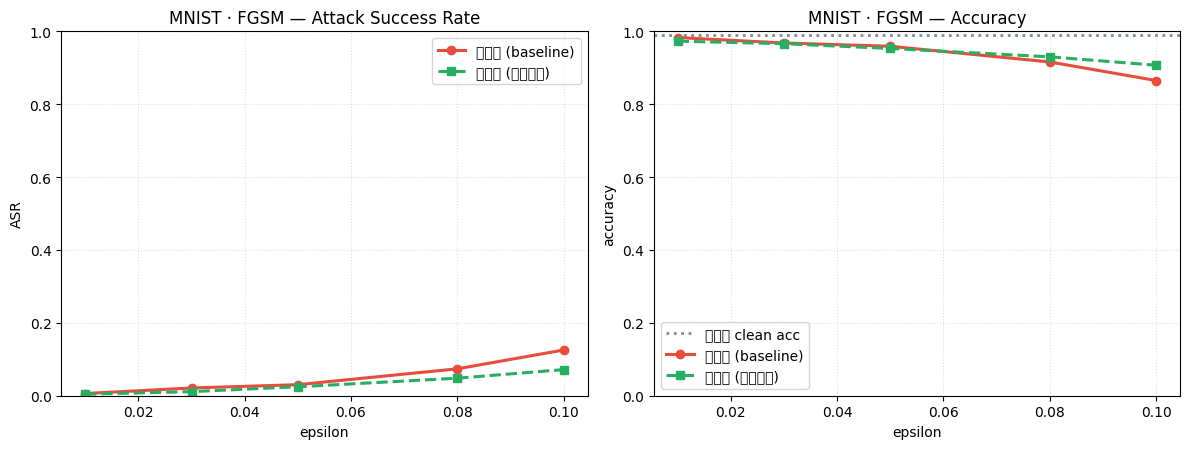

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

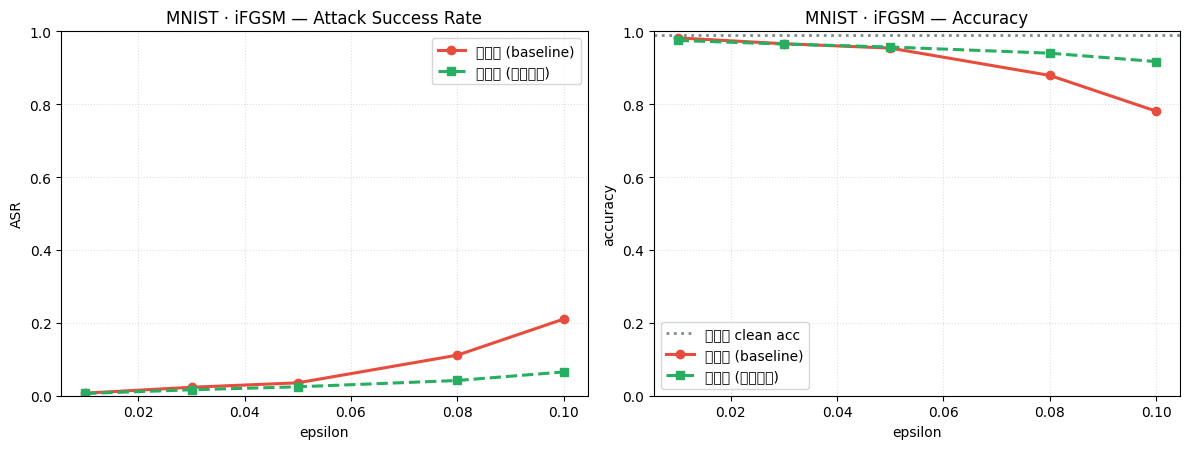

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

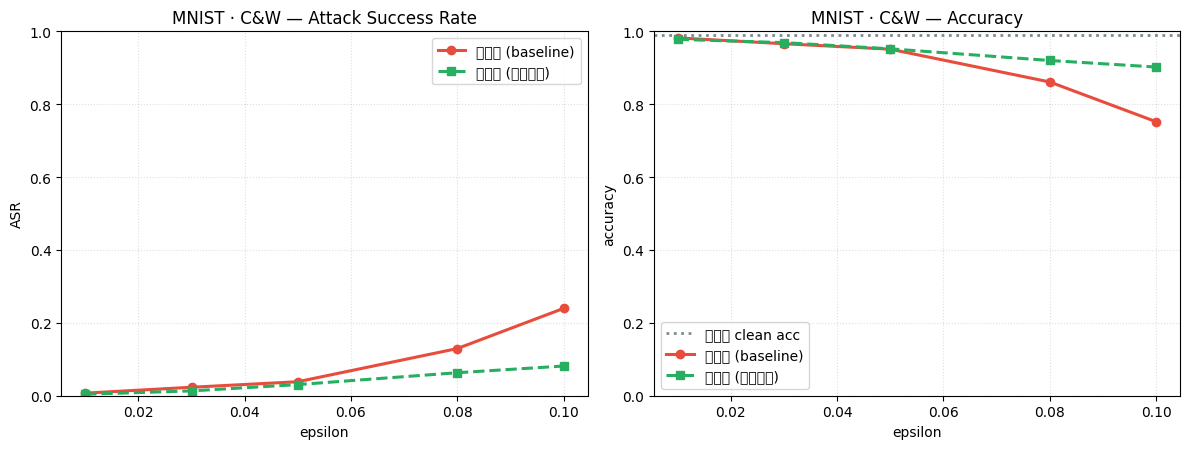

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

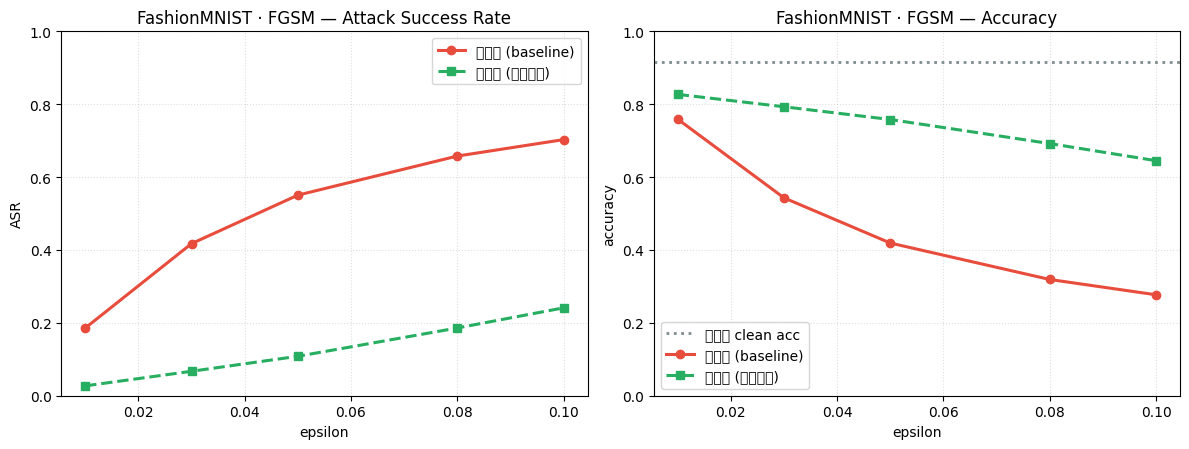

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

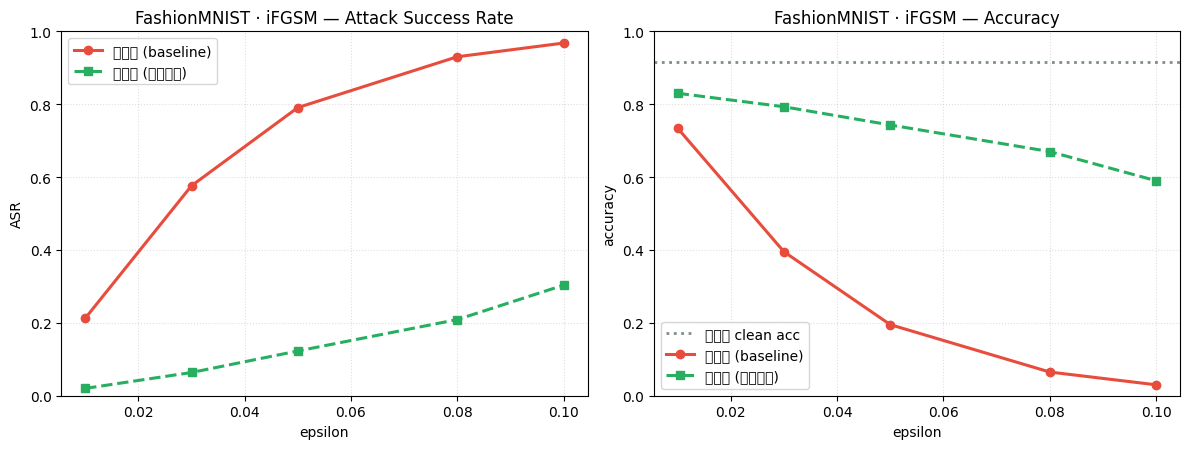

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

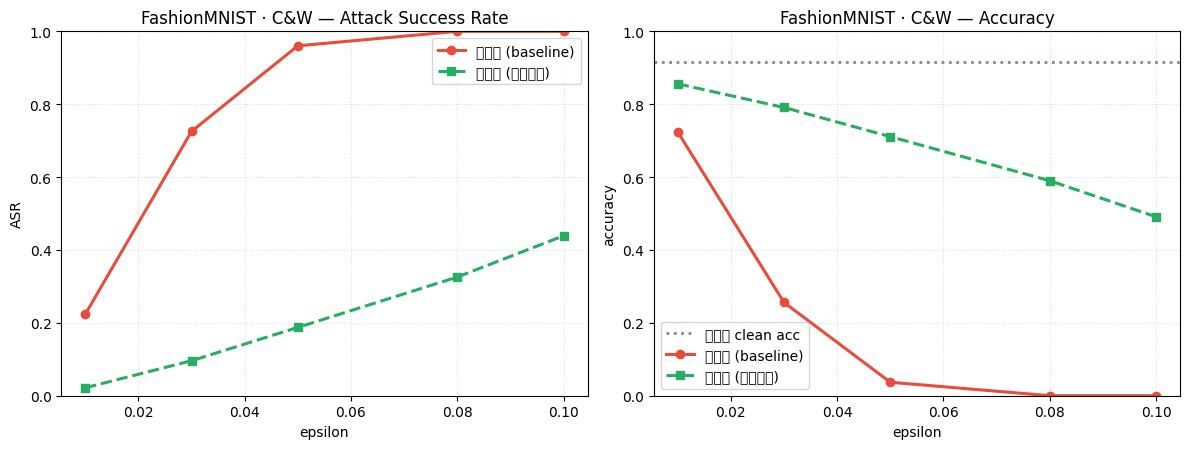

In [10]:
for name in DATASETS:
    for attack in ATTACKS:
        plot_attack_chart(name, attack, SWEEP[name][attack], CLEAN_ACC[name])

In [11]:
rows = []
for name in DATASETS:
    for attack in ATTACKS:
        r = SWEEP[name][attack]
        i = -3  
        rows.append({
            "Dataset": name, "Attack": attack, "eps": r["eps"][i],
            "ASR baseline": r["asr_base"][i], "ASR defended": r["asr_def"][i],
            "ASR 下降": r["asr_base"][i] - r["asr_def"][i],
            "Acc baseline": r["acc_base"][i], "Acc defended": r["acc_def"][i],
            "Acc 恢復": r["acc_def"][i] - r["acc_base"][i],
        })
summary = pd.DataFrame(rows).set_index(["Dataset", "Attack"])
print("===== 對抗訓練成效摘要（各攻擊最大 epsilon）=====")
display(summary.round(4))
summary.round(4).to_csv(os.path.join(IMG_DIR, "defense_summary.csv"))

===== 對抗訓練成效摘要（各攻擊最大 epsilon）=====


eps  ASR baseline  ASR defended  ASR 下降  Acc baseline  \
Dataset      Attack                                                           
MNIST        FGSM    0.05        0.0303        0.0246  0.0058         0.959   
             iFGSM   0.05        0.0354        0.0245  0.0109         0.954   
             C&W     0.05        0.0384        0.0305  0.0079         0.951   
FashionMNIST FGSM    0.05        0.5504        0.1082  0.4422         0.419   
             iFGSM   0.05        0.7908        0.1228  0.6680         0.195   
             C&W     0.05        0.9603        0.1874  0.7729         0.037   

                     Acc defended  Acc 恢復  
Dataset      Attack                        
MNIST        FGSM           0.953  -0.006  
             iFGSM          0.957   0.003  
             C&W            0.952   0.001  
FashionMNIST FGSM           0.758   0.339  
             iFGSM          0.743   0.548  
             C&W            0.711   0.674